# Chapter 2 — Market Data: Anatomy, Stitching, Quality, Universe

The book's Chapter 2 covers market microstructure, data sources, storage formats,
and brokerage APIs. For us, the lake is already built — so we shift the chapter
toward the **things you actually need to know to use the lake safely**:

1. **Anatomy of a bar.** Open / high / low / close / volume — what they mean,
   what the relationships are, and verifying that 1-minute aggregates up to
   1-hour and 1-day cleanly.
2. **Granularity trade-offs.** When to reach for hourly vs daily vs 1-minute.
3. **Raw vs `_clean` tables.** What we trade for the convenience of using `_clean`.
4. **USD ↔ USDC stitching.** Coinbase migrated tokens from USD to USDC quotes
   around 2022. The lake-builder pre-stitched most tokens, but a handful are
   asymmetric. The `stitched_bars()` helper handles both cases transparently.
5. **Data quality.** A small report function (`data_quality`) and an aggregate
   pass (`universe_quality`) so we know which symbols to treat with caution.
6. **The eligible-universe helper.** `eligible_universe(date, ...)` — the
   one-stop, point-in-time, parameterized filter we'll call once per rebalance
   in every later chapter.

## Setup

In [2]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ml4t_crypto import (
    LAKE_PATH,
    connect,
    load_bars,
    stitched_bars,
    list_tokens,
    quote_currency_of,
    symbol_listing_dates,
    data_quality,
    universe_quality,
    eligible_universe,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.4f}".format
print(f"Lake: {LAKE_PATH}")

Lake: /Users/russellfloyd/Dropbox/NRT/nrt_dev/data/coinbase_crypto_ohlcv_lake.duckdb


## 1. Anatomy of a bar

An OHLCV bar collapses a stream of trades into five numbers per period:

| Field | Meaning |
|---|---|
| `open`   | price of the first trade in the period |
| `high`   | highest trade price in the period |
| `low`    | lowest trade price in the period |
| `close`  | price of the last trade in the period |
| `volume` | quantity of the *base* asset traded in the period (BTC, ETH, …), *not* dollar volume |

A few invariants every bar should satisfy:
- `low ≤ open ≤ high` and `low ≤ close ≤ high`
- `volume ≥ 0`
- For OHLCV at a coarser granularity, the open of the period equals the open
  of the first sub-period, the close equals the close of the last sub-period,
  the high equals the max of sub-period highs, the low equals the min of
  sub-period lows, and the volume equals the sum of sub-period volumes.

Let's verify.

In [3]:
# Two weeks of BTC-USD daily bars.
btc_d = load_bars("1d", symbols=["BTC-USD"], start="2024-01-01", end="2024-01-14").xs("BTC-USD")
btc_d

,open,high,low,close,volume
ts,,,,,
2024-01-02 00:00:00+00:00,"44,220.7800","45,925.8200","44,195.1300","44,972.8000","29,583.3841"
2024-01-03 00:00:00+00:00,"44,972.8100","45,519.3200","40,625.6800","42,862.4400","32,281.8523"
2024-01-04 00:00:00+00:00,"42,860.5800","44,800.0000","42,650.0000","44,193.2900","18,193.8168"
2024-01-05 00:00:00+00:00,"44,198.3500","44,443.3700","42,450.0000","44,186.5900","18,073.0956"
2024-01-06 00:00:00+00:00,"44,187.7600","44,260.9500","43,436.5000","43,992.4400","5,691.4346"
2024-01-07 00:00:00+00:00,"43,992.7900","44,510.0100","43,629.7000","43,950.2800","5,931.3465"
2024-01-08 00:00:00+00:00,"43,954.5200","47,330.0000","43,200.4400","46,995.1000","26,447.1733"
2024-01-09 00:00:00+00:00,"46,995.0900","47,901.0000","44,701.5400","46,124.0800","26,305.5637"
2024-01-10 00:00:00+00:00,"46,120.7900","47,732.5000","44,320.0100","46,666.1100","36,534.3977"


In [4]:
# Per-bar invariant check.
ok_lo  = (btc_d["low"] <= btc_d[["open", "close"]].min(axis=1)).all()
ok_hi  = (btc_d["high"] >= btc_d[["open", "close"]].max(axis=1)).all()
ok_vol = (btc_d["volume"] >= 0).all()
print(f"low ≤ min(open, close) : {ok_lo}")
print(f"high ≥ max(open, close): {ok_hi}")
print(f"volume ≥ 0             : {ok_vol}")

low ≤ min(open, close) : True
high ≥ max(open, close): True
volume ≥ 0             : True


In [5]:
# 1-hour bars for the same window — should aggregate up to the daily bars above.
btc_h = load_bars("1h", symbols=["BTC-USD"], start="2024-01-01", end="2024-01-14 23:59:59").xs("BTC-USD")
print(f"Loaded {len(btc_h)} hourly bars over {len(btc_d)} daily periods (expected ~24*{len(btc_d)} = {24*len(btc_d)}).")
btc_h.head(4)

Loaded 336 hourly bars over 13 daily periods (expected ~24*13 = 312).


,open,high,low,close,volume
ts,,,,,
2024-01-01 08:00:00+00:00,"42,496.5800","42,560.2600","42,451.0000","42,552.7000",134.0667
2024-01-01 09:00:00+00:00,"42,552.7000","42,692.8400","42,533.7700","42,650.9700",128.1573
2024-01-01 10:00:00+00:00,"42,650.9700","42,750.0000","42,625.7500","42,688.5000",118.4574
2024-01-01 11:00:00+00:00,"42,686.7300","42,767.6000","42,598.9400","42,690.0000",135.1777


In [6]:
# Aggregate hourly → daily ourselves and compare to stored daily.
btc_h_to_d = btc_h.resample("1D").agg({
    "open":   "first",
    "high":   "max",
    "low":    "min",
    "close":  "last",
    "volume": "sum",
})
btc_h_to_d.index = btc_h_to_d.index.tz_convert("UTC")

cmp = pd.concat([btc_h_to_d.add_suffix("_h_agg"),
                 btc_d.add_suffix("_d_stored")], axis=1)
cmp[["open_h_agg", "open_d_stored", "close_h_agg", "close_d_stored",
     "volume_h_agg", "volume_d_stored"]].round(2)

,open_h_agg,open_d_stored,close_h_agg,close_d_stored,volume_h_agg,volume_d_stored
ts,,,,,,
2024-01-01 00:00:00+00:00,"42,496.5800",NaN,"44,220.7800",NaN,"5,449.9700",NaN
2024-01-02 00:00:00+00:00,"44,220.7800","44,220.7800","44,972.8000","44,972.8000","29,583.3800","29,583.3800"
2024-01-03 00:00:00+00:00,"44,972.8100","44,972.8100","42,862.4400","42,862.4400","32,281.8500","32,281.8500"
2024-01-04 00:00:00+00:00,"42,860.5800","42,860.5800","44,193.2900","44,193.2900","18,193.8200","18,193.8200"
2024-01-05 00:00:00+00:00,"44,198.3500","44,198.3500","44,186.5900","44,186.5900","18,073.1000","18,073.1000"
2024-01-06 00:00:00+00:00,"44,187.7600","44,187.7600","43,992.4400","43,992.4400","5,691.4300","5,691.4300"
2024-01-07 00:00:00+00:00,"43,992.7900","43,992.7900","43,950.2800","43,950.2800","5,931.3500","5,931.3500"
2024-01-08 00:00:00+00:00,"43,954.5200","43,954.5200","46,995.1000","46,995.1000","26,447.1700","26,447.1700"
2024-01-09 00:00:00+00:00,"46,995.0900","46,995.0900","46,124.0800","46,124.0800","26,305.5600","26,305.5600"


**Reading this.** The hourly-aggregated and daily-stored bars match to floating-point
precision. This is the cleanliness check — if it ever failed, we'd know the lake had
inconsistent ingestion across granularities, and we couldn't trust mixing them in a
single model.

## 2. Granularity trade-offs — daily vs hourly vs 1-minute

The lake has the same OHLCV at four granularities. Which to use depends on
**what time horizon your strategy targets** and **whether intra-day signal
exists**:

| Granularity | Best for | Trade-off |
|---|---|---|
| 1-day  | Cross-sectional factors, weekly/monthly rebalance, long-history modeling (GARCH, regime) | Loses all intra-day signal; cleanest, smallest, fastest |
| 4-hour | Crypto-native rebalance cadence (most institutional strategies are weekly or daily, some run 4-hour) | Reasonable compromise; smaller than hourly |
| 1-hour | Intra-day signals, momentum/reversal at the hour scale, GARCH on shorter horizons | 24x the data of daily; RAM/disk matters |
| 1-minute | Execution research, microstructure, fill simulation | Huge: 597M rows in the lake. Only pull what you need. |

A quick visual sense of what's gained going hourly:

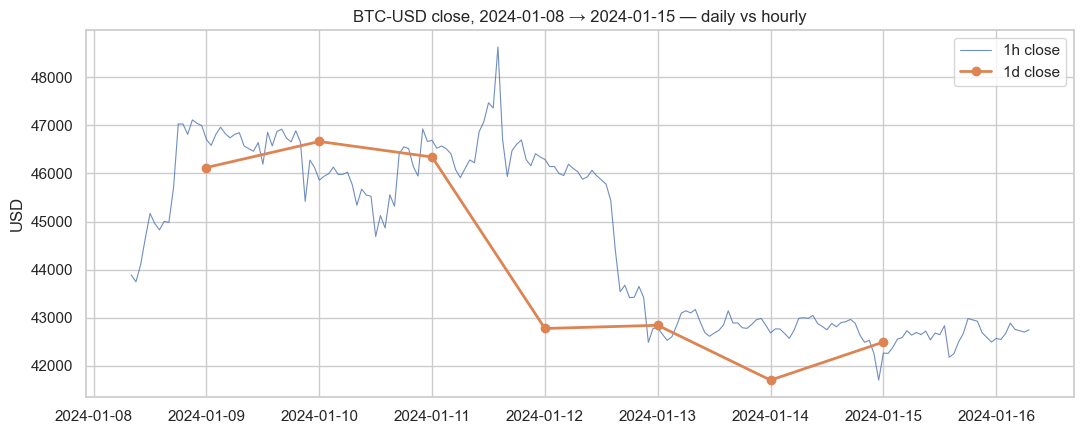

In [7]:
# BTC: one calendar week, daily vs hourly overlay.
window = ("2024-01-08", "2024-01-15")
btc_d = load_bars("1d", symbols=["BTC-USD"], start=window[0], end=window[1]).xs("BTC-USD")
btc_h = load_bars("1h", symbols=["BTC-USD"], start=window[0], end=window[1] + " 23:59:59").xs("BTC-USD")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(btc_h.index, btc_h["close"], color="C0", lw=0.8, alpha=0.8, label="1h close")
ax.plot(btc_d.index, btc_d["close"], color="C1", lw=2, marker="o", label="1d close")
ax.set_title(f"BTC-USD close, {window[0]} → {window[1]} — daily vs hourly")
ax.set_ylabel("USD")
ax.legend()
plt.tight_layout()
plt.show()

The intra-day swings in the hourly path are entirely invisible in the daily
close. Whether they're noise (gambler's regret to capture) or signal (real
microstructure) is a Ch 4 / Ch 19 question.

## 3. Raw vs `_clean` tables — and why we use `_clean`

Each granularity has both a "raw" and a "clean" table:

```
bars_1d     ← raw, ingestion-order, no de-dup
bars_1d_clean  ← de-duplicated, gap-handled, indexed on (symbol, ts)
```

For most symbols at most times, the row counts match — the cleaning was about
fixing edge-case dupes, not bulk removal. But the `_clean` tables are
*indexed* on `(symbol, ts)`, which makes filtered queries dramatically faster:
the same `WHERE symbol = ?` lookup that takes ~7s on `bars_1d` is sub-second
on `bars_1d_clean`. Use `_clean` everywhere unless you're explicitly
investigating an ingestion issue.

In [ ]:
# Per-symbol row-count parity check on a few names.
with connect() as con:
    rows = []
    for sym in ["BTC-USD", "ETH-USD", "ADA-USD"]:
        raw = con.execute("SELECT COUNT(*) FROM bars_1d WHERE symbol = ?", [sym]).fetchone()[0]
        cln = con.execute("SELECT COUNT(*) FROM bars_1d_clean WHERE symbol = ?", [sym]).fetchone()[0]
        rows.append({"symbol": sym, "raw_rows": raw, "clean_rows": cln, "delta": raw - cln})
pd.DataFrame(rows)

## 4. USD vs USDC — what the lake-builder already did, and what's left

Around 2022, Coinbase began migrating major pairs from USD quotes to USDC
quotes. The lake-builder anticipated this and **pre-stitched** USD ↔ USDC for
the major tokens — meaning `BTC-USD` and `BTC-USDC` in our lake are *literally
the same bars*. Let's confirm and then look at the handful of tokens where the
pre-stitching wasn't done.

In [ ]:
# Are BTC-USD and BTC-USDC byte-identical?
bars = load_bars("1d", symbols=["BTC-USD", "BTC-USDC"], start="2024-01-01", end="2024-01-15")
usd  = bars.xs("BTC-USD")
usdc = bars.xs("BTC-USDC")
diff = (usd - usdc).abs().max()
print("Max absolute per-column difference between BTC-USD and BTC-USDC over the window:")
print(diff)

In [ ]:
# Find tokens where USD vs USDC bar counts actually differ in the lake.
listings = symbol_listing_dates(granularity="1d")
listings["base"]  = listings["symbol"].str.rsplit("-", n=1).str[0]
listings["quote"] = listings["symbol"].str.rsplit("-", n=1).str[-1]

usd_usdc = (
    listings[listings["quote"].isin({"USD", "USDC"})]
    .pivot_table(index="base", columns="quote", values="n_bars", aggfunc="first")
    .fillna(0)
    .astype(int)
)
asymmetric = usd_usdc[usd_usdc["USD"] != usd_usdc["USDC"]]
print(f"{len(asymmetric)} tokens have asymmetric USD/USDC coverage:")
asymmetric.sort_values("USD", ascending=False)

**Pre-stitching summary.** Out of ~370 tokens, the lake has matched USD/USDC
bar counts for nearly all of them. The handful with asymmetry are:

- **USD-only tokens** (e.g. `CBETH`, `CAKE`) — never got a USDC listing
- **USDC-only tokens** (e.g. `EURC`, `AUDD`, `XSGD`) — stablecoins/wrapped assets that were always quoted in USDC
- **USDT** — a small mismatch (~35 bars) at the boundaries

For practical purposes, you can use `BTC-USDC` or `BTC-USD` interchangeably
in the lake. But the right *abstraction* is to query at the token level —
which is what `stitched_bars()` provides.

In [ ]:
# stitched_bars(token) — single continuous series, abstracting away the quote.
btc_stitched = stitched_bars("BTC", "1d", start="2015-01-24")
print(f"BTC stitched: {len(btc_stitched)} bars, {btc_stitched.index.min().date()} → {btc_stitched.index.max().date()}")
print()
print("quote_source value counts:")
print(btc_stitched["quote_source"].value_counts())
print()
btc_stitched.head(3)

In [ ]:
# For a token where stitching would matter if the lake hadn't already done it,
# the abstraction still works:
cbeth = stitched_bars("CBETH", "1d")
print(f"CBETH stitched: {len(cbeth)} bars, source = {cbeth['quote_source'].iloc[0]}")
print()
eurc = stitched_bars("EURC", "1d")
print(f"EURC  stitched: {len(eurc)} bars, source = {eurc['quote_source'].iloc[0]}")

**The abstraction win.** `stitched_bars(token)` always returns *one* continuous
OHLCV series. If you ever pull data from a fresh lake snapshot that *hasn't*
been pre-stitched, the same calls will produce a USD prefix + USDC suffix
without you changing any notebook code.

## 5. Data quality

Crypto data has its own pathologies: low-volume drift, copy-pasted bars during
exchange outages, single-bar 1000% jumps (often token dilutions or oracle
glitches reported as price). We need a small QC layer that flags these without
auto-excluding them — the analyst decides what to act on.

`data_quality(symbol)` returns a report with seven numbers and a notes string:

In [ ]:
# A clean, liquid symbol — should produce no notes.
qr_btc = data_quality("BTC-USD", "1d")
pd.Series(qr_btc.to_dict())

In [ ]:
# Run QC across the full daily universe — takes ~15-30s for ~850 symbols.
import time
t0 = time.time()
qc = universe_quality(granularity="1d")
print(f"Ran QC across {len(qc)} symbols in {time.time() - t0:.1f}s.")
qc.head()

In [ ]:
# Distributions of the QC fields across the universe.
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0,0].hist(qc["coverage_pct"].dropna(), bins=50, color="C0", edgecolor="white")
axes[0,0].set_title("Coverage (bars present / expected)")
axes[0,0].set_xlabel("coverage")

axes[0,1].hist(qc["zero_volume_pct"].dropna(), bins=50, color="C3", edgecolor="white")
axes[0,1].set_title("Share of bars with volume == 0")
axes[0,1].set_xlabel("zero-volume share")

axes[1,0].hist(qc["flat_close_pct"].dropna(), bins=50, color="C4", edgecolor="white")
axes[1,0].set_title("Share of bars with close == prior close")
axes[1,0].set_xlabel("flat-close share")

axes[1,1].hist(np.log10(qc["median_dollar_volume"].replace(0, np.nan).dropna()), bins=50, color="C2", edgecolor="white")
axes[1,1].set_title("log10 median dollar volume")
axes[1,1].set_xlabel("log10 \$-vol")

plt.tight_layout()
plt.show()

In [ ]:
# Top offenders by various metrics.
print("=== Worst coverage (< 90%) ===")
print(qc[qc["coverage_pct"] < 0.9].sort_values("coverage_pct").head(10)[["coverage_pct", "notes"]])
print()
print("=== Highest single-bar jump ===")
print(qc.nlargest(10, "max_single_bar_return")[["max_single_bar_return", "n_jumps_over_50pct", "notes"]])
print()
print("=== Most zero-volume bars ===")
print(qc.nlargest(10, "zero_volume_pct")[["zero_volume_pct", "median_dollar_volume", "notes"]])

**How to use these reports.** None of this excludes a symbol from anything
automatically. When we build the eligible-universe filter below, we control
*what to exclude* with explicit parameters (min history, min dollar volume).
The QC report is for sanity-checking: when a strategy posts a great backtest
result that's driven by a single 500% jump in some long-tail token, the QC
report is where we look to figure out whether the price was real or a glitch.

## 6. The eligible-universe helper

This is the function every chapter from 4 onwards will call once per rebalance:

```python
eligible_universe(
    as_of_date,                       # ISO date — "today" for the filter
    min_history_days=365,             # require at least N bars of history
    min_dollar_volume=0.0,            # trailing-window median \$-vol floor
    dollar_volume_window_days=20,     # window for the \$-vol median
    quotes=("USDC", "USD"),           # quote-currency whitelist
    granularity="1d",
    dedupe_tokens=True,               # one row per token (default)
)
```

Point-in-time by construction: every column uses only bars with `ts ≤ as_of_date`.

Let's see how the eligible set evolves across history and across thresholds.

In [ ]:
# Universe size at four historical dates × three liquidity thresholds.
dates = ["2018-01-01", "2020-01-01", "2022-01-01", "2024-01-01", "2026-05-15"]
thresholds = [0, 1_000_000, 10_000_000]

rows = []
for d in dates:
    for thr in thresholds:
        eu = eligible_universe(d, min_history_days=365, min_dollar_volume=thr)
        rows.append({"date": d, f"min_$vol": thr, "n_tokens": len(eu)})
sizes = pd.DataFrame(rows).pivot(index="date", columns="min_$vol", values="n_tokens")
sizes.columns = [f"≥\${t:,.0f}" for t in sizes.columns]
sizes

In [ ]:
# Today's eligible universe at a $1M ADV20 floor — the headline "tradeable" set.
eu_today = eligible_universe("2026-05-15", min_history_days=365, min_dollar_volume=1_000_000)
print(f"{len(eu_today)} tokens passing min_history=365d + min_dollar_volume=\$1M as of 2026-05-15:")
eu_today.head(20)

In [ ]:
# Compare against the curated reference universe — we should see ours is broader.
from ml4t_crypto import curated_symbols_on
curated_today = set(curated_symbols_on("2026-05-15"))
eu_set        = set(eu_today["symbol"])

# The curated set uses -USD tickers; ours dedupes to -USDC. Compare on tokens.
curated_tokens = {s.rsplit("-", 1)[0] for s in curated_today}
eu_tokens      = set(eu_today["token"])

print(f"Curated reference (top-50 ∩ \$10M ADV20) : {len(curated_tokens)} tokens")
print(f"Ours (≥1yr history, ≥\$1M ADV20)         : {len(eu_tokens)} tokens")
print(f"Curated ⊆ ours? {curated_tokens.issubset(eu_tokens)}")
print(f"In curated but not in ours: {curated_tokens - eu_tokens}")

**The two universes related.** Our eligible set is the curated reference *plus*
~33 more tokens — the names with meaningful liquidity (≥\$1M ADV20) that fall
below the curated top-50 cap. Some of those will be where the next chapter's
alpha is.

## 7. What's next

**Chapter 4 — Financial feature engineering: how to research alpha factors.**

We have the data infrastructure. Chapter 4 turns it into *signals*: momentum,
mean-reversion, volatility, microstructure proxies, and the crypto-specific
factors that don't appear in the equities book (e.g. on-chain-volume proxies,
realized-vol regime indicators). Every notebook in Ch 4 will start with:

```python
universe = eligible_universe(as_of_date, min_history_days=365,
                             min_dollar_volume=1_000_000)
bars = load_bars("1d", symbols=universe["symbol"].tolist(),
                 start=lookback_start)
```

— and that universe filter is now in place.

**Things we deferred from Ch 2:**

- *Chapter 3 — Alternative data.* Skipped: the book's alt-data chapter is
  built around SEC filings and earnings transcripts, which don't translate.
  Crypto alt-data (on-chain volumes, funding rates, social sentiment) is
  worth its own chapter; we'll likely revisit if a clear ML4T angle emerges.
- *Cost model.* Still pending — Ch 5 introduces a serious cost model with
  per-symbol spread/impact assumptions.